In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

# Apply same cleaning as Person A
matches['winner'].fillna('No Result', inplace=True)
matches.dropna(subset=['city'], inplace=True)

team_rename = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants'
}

for col in ['team1', 'team2', 'winner']:
    matches[col] = matches[col].replace(team_rename)

print("Data ready ✓")

Data ready ✓


In [3]:
print("=== Dataset Overview ===")
print(f"Seasons covered: {sorted(matches['season'].unique())}")
print(f"Total matches: {len(matches)}")
print(f"Total teams: {matches['team1'].nunique()}")
print(f"Total venues: {matches['venue'].nunique()}")
print(f"Total deliveries: {len(deliveries)}")

print("\n=== Matches per Season ===")
print(matches['season'].value_counts().sort_index())

=== Dataset Overview ===
Seasons covered: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
Total matches: 1044
Total teams: 16
Total venues: 58
Total deliveries: 260920

=== Matches per Season ===
season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       47
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    22
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64


In [4]:
deliveries[['batsman_runs', 'extra_runs', 'total_runs']].describe().round(2)

,batsman_runs,extra_runs,total_runs
count,260920.00,260920.00,260920.00
mean,1.27,0.07,1.33
std,1.64,0.34,1.63
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,1.00,0.00,1.00
75%,1.00,0.00,1.00
max,6.00,7.00,7.00


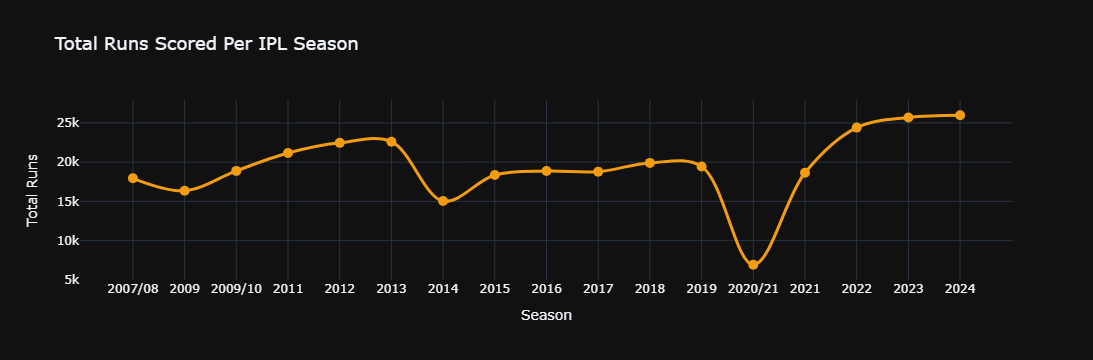

In [5]:
season_runs = (
    deliveries.merge(matches[['id', 'season']], left_on='match_id', right_on='id')
    .groupby('season')['total_runs']
    .sum()
    .reset_index()
)

import plotly.express as px

fig = px.line(
    season_runs,
    x='season',
    y='total_runs',
    markers=True,
    title='Total Runs Scored Per IPL Season',
    labels={'season': 'Season', 'total_runs': 'Total Runs'},
    template='plotly_dark',
    line_shape='spline'
)

fig.update_traces(line_color='#f39c12', line_width=3, marker_size=10)
fig.update_layout(title_font_size=18, hovermode='x unified')

fig.write_html('chart4_season_runs.html')  # saves file
fig.show()

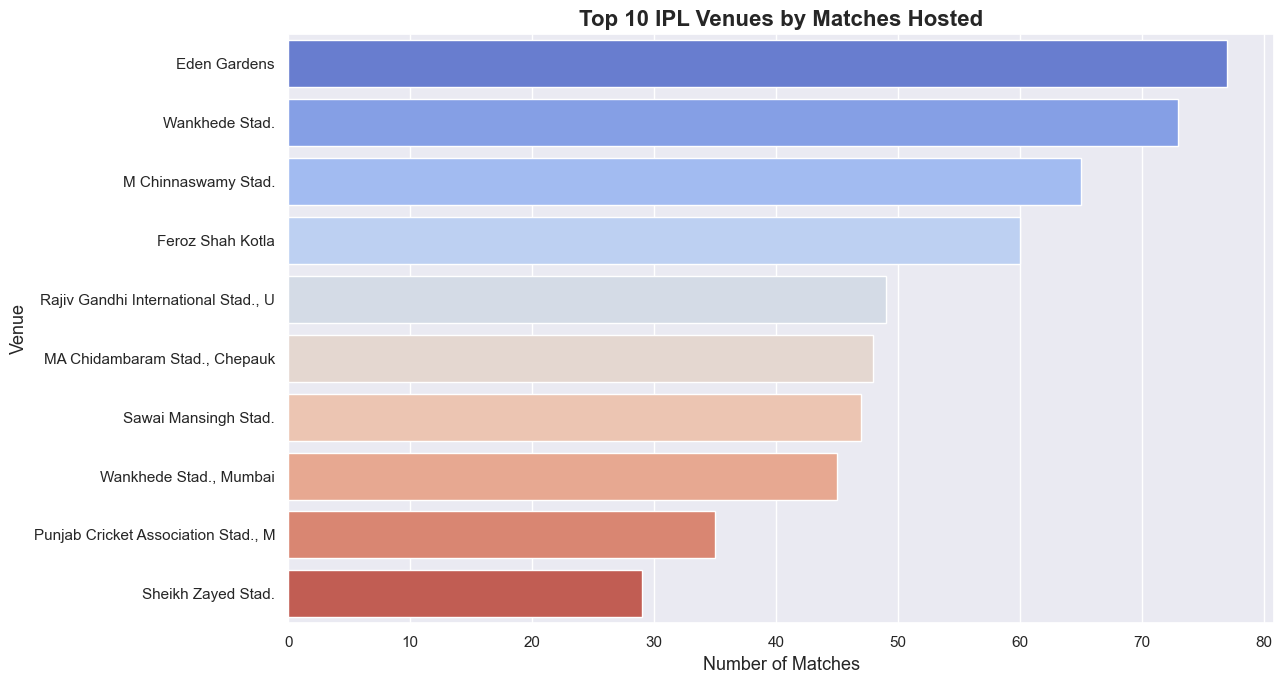

In [6]:
top_venues = matches['venue'].value_counts().head(10).reset_index()
top_venues.columns = ['venue', 'matches']

# Shorten long names (clean look)
top_venues['venue'] = top_venues['venue'].str.replace('Stadium', 'Stad.').str[:35]

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(13, 7))

sns.barplot(
    data=top_venues,
    x='matches',
    y='venue',
    palette='coolwarm',
    ax=ax
)

ax.set_title('Top 10 IPL Venues by Matches Hosted', fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Matches', fontsize=13)
ax.set_ylabel('Venue', fontsize=13)

plt.tight_layout()
plt.savefig('chart5_venues.png', dpi=150)
plt.show()

In [7]:
ml_data = matches[['toss_decision', 'venue', 'season', 'toss_winner', 'winner']].copy()

# Remove no result matches
ml_data = ml_data[ml_data['winner'] != 'No Result']

# Target variable (0 or 1)
ml_data['toss_won_match'] = (ml_data['toss_winner'] == ml_data['winner']).astype(int)

ml_data.head()

,toss_decision,venue,season,toss_winner,winner,toss_won_match
0,field,M Chinnaswamy Stadium,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,0
1,bat,"Punjab Cricket Association Stadium, Mohali",2007/08,Chennai Super Kings,Chennai Super Kings,1
2,bat,Feroz Shah Kotla,2007/08,Rajasthan Royals,Delhi Capitals,0
3,bat,Wankhede Stadium,2007/08,Mumbai Indians,Royal Challengers Bangalore,0
4,bat,Eden Gardens,2007/08,Deccan Chargers,Kolkata Knight Riders,0


In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()

ml_data['toss_decision_enc'] = le.fit_transform(ml_data['toss_decision'])
ml_data['venue_enc'] = le.fit_transform(ml_data['venue'])

# Fix season column (convert to numeric)
ml_data['season'] = ml_data['season'].astype(str).str[:4].astype(int)

# Features and target (IMPORTANT: separate lines)
X = ml_data[['toss_decision_enc', 'venue_enc', 'season']]
y = ml_data['toss_won_match']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split done ✓")

Data split done ✓


In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained ✓")

Model trained ✓


In [14]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 50.00%

Classification Report:

              precision    recall  f1-score   support

           0       0.52      0.48      0.50       108
           1       0.48      0.52      0.50       100

    accuracy                           0.50       208
   macro avg       0.50      0.50      0.50       208
weighted avg       0.50      0.50      0.50       208

